In [1]:
record_name = '082620_355l'

In [2]:
import sys
sys.path.append('../src')
from should_be_stdlib import resample_log
from neurodata import *
from data import *

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import Akima1DInterpolator

In [4]:
record = load_set(record_name)
tuning_curves = get_tc(record)
coords = get_xyz(record)

In [5]:
#### ½ octave with equal temperament (reasonable guess)
old_freqs = resample_log([3, 3*2**4], 9)
new_freqs = resample_log([3, 3*2**4], 16)
old_freqs, new_freqs

(array([ 3.        ,  4.24264069,  6.        ,  8.48528137, 12.        ,
        16.97056275, 24.        , 33.9411255 , 48.        ]),
 array([ 3.        ,  3.60907511,  4.34180771,  5.22330338,  6.28376474,
         7.5595263 ,  9.0942994 , 10.94066986, 13.16189976, 15.83409493,
        19.04881262, 22.91619849, 27.56876052, 33.16590912, 39.89941901,
        48.        ]))

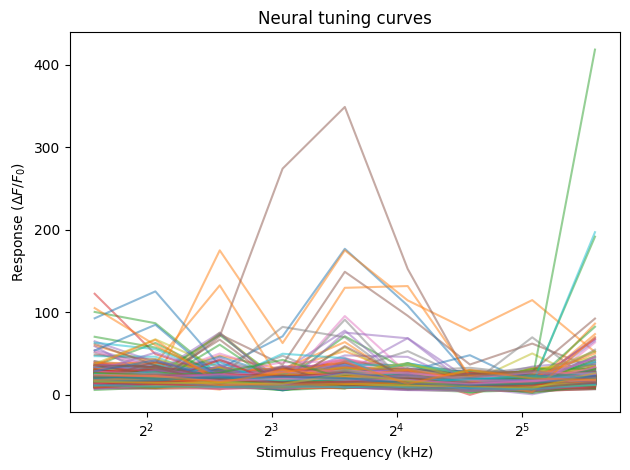

In [6]:
tuning_curves.columns = old_freqs.round(1)
plt.plot(tuning_curves.T, alpha=0.5)
plt.title('Neural tuning curves')
plt.xlabel('Stimulus Frequency (kHz)')
plt.ylabel('Response ($ΔF/F_0$)')
plt.xscale('log', base=2)
plt.tight_layout()
plt.savefig(figspath(record_name, 'tuning-curves.png'), dpi=300)
plt.show()

In [7]:
# rescale tuning curves
def normalize(x, c=1):
    """Normalize vector and rescale to c"""
    # Multiply then divide for numerical stability
    return x * c / np.linalg.norm(x, ord=1)

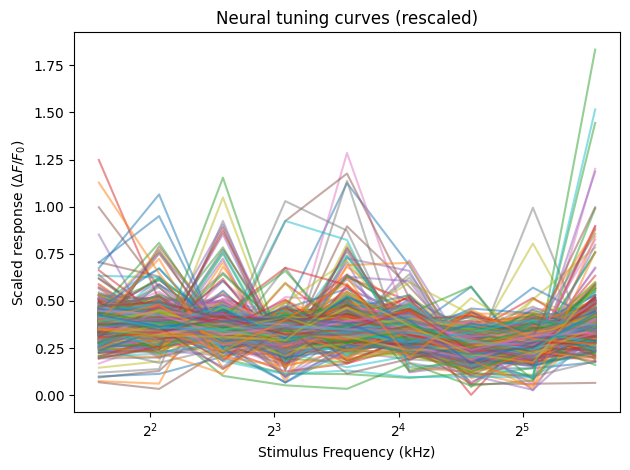

In [8]:
# tuning curves can't be negative. scale to pi so values range from [0, pi]
tuning_curves_rescaled = tuning_curves.apply(
    lambda x: normalize(x, c=np.pi),
    axis=1,
    result_type='expand',
)
tuning_curves_rescaled.to_csv(datapath(record_name, 'data_tuning-curves_rescaled.csv'))
plt.plot(tuning_curves_rescaled.T, alpha=0.5)
plt.title('Neural tuning curves (rescaled)')
plt.xlabel('Stimulus Frequency (kHz)')
plt.ylabel('Scaled response ($ΔF/F_0$)')
plt.xscale('log', base=2)
plt.tight_layout()
plt.savefig(figspath(record_name, 'tuning-curves-rescaled.png'), dpi=300)
plt.show()

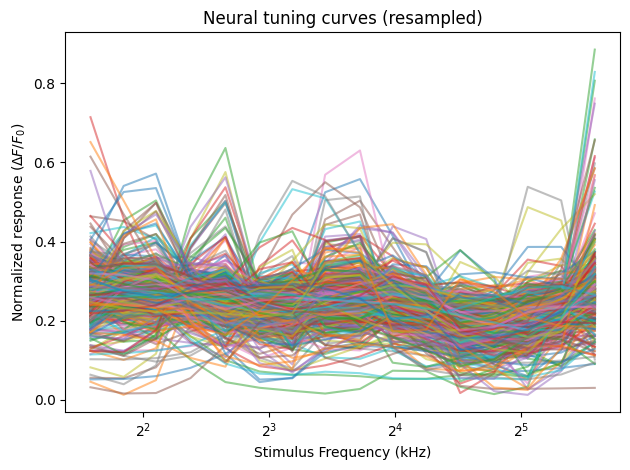

,3.0,3.6,4.3,5.2,6.3,7.6,9.1,10.9,13.2,15.8,19.0,22.9,27.6,33.2,39.9,48.0
0,16.021952,12.264374,10.553161,12.029935,13.122600,13.450016,13.010839,11.518352,11.122062,12.595746,11.502252,7.909172,7.048282,7.917080,10.621251,15.571267
1,20.064707,20.752571,21.122397,20.827353,20.051630,17.770461,17.547947,26.211134,27.404850,20.978064,17.578633,15.242605,15.379164,15.998573,16.954879,18.228867
2,21.028196,22.277563,22.195533,19.621125,16.698515,14.074841,13.886597,18.145316,18.363760,14.071747,12.964050,12.832966,13.385413,14.358616,16.401317,20.008920
3,20.785587,21.245353,21.440447,20.860618,19.153457,12.819672,10.760235,18.601808,20.675987,19.282885,17.112897,14.406771,11.495370,8.899217,11.143003,20.654751
4,18.029279,21.411037,22.614818,20.201781,17.622655,15.291523,14.855633,15.996911,17.019773,17.930467,17.045457,14.110422,14.316464,15.329190,16.165761,17.052216
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
747,18.318777,18.182978,18.752275,21.199309,22.812186,22.574898,21.651194,20.058235,19.826921,21.194114,21.519719,20.893221,23.251630,28.491325,27.649828,20.203424
748,16.204639,15.252283,14.632428,14.494233,14.314331,13.749321,14.395782,22.753331,24.111655,18.925143,14.775293,10.859066,8.378430,7.867087,13.051002,26.544237
749,11.726129,10.699232,10.043401,9.818680,9.843671,10.184279,10.243572,9.877369,9.576391,9.360883,8.936871,8.298417,7.565123,6.844920,7.990347,12.274010
750,22.926113,20.658770,19.633473,20.406698,21.190711,21.834027,22.063205,21.249501,19.241030,15.179924,12.950753,11.732424,11.985682,13.379365,16.819925,23.284852


In [9]:
# upsample the tuning curves to fill the binary space
tuning_curves_resampled = tuning_curves.apply(
    lambda response: Akima1DInterpolator(old_freqs, response, method='makima')(new_freqs),
    axis=1,
    result_type='expand',
)
tuning_curves_resampled.columns = new_freqs.round(1)
tuning_curves_resampled.to_csv(datapath(record_name, 'data_tuning-curves_resampled.csv'))
plt.plot(tuning_curves_resampled.T.apply(lambda x: x / np.linalg.norm(x)), alpha=0.5)
plt.title('Neural tuning curves (resampled)')
plt.xlabel('Stimulus Frequency (kHz)')
plt.ylabel('Normalized response ($ΔF/F_0$)')
plt.xscale('log', base=2)
plt.tight_layout()
plt.savefig(figspath(record_name, 'tuning-curves-resampled.png'), dpi=300)
plt.show()
tuning_curves_resampled